In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, smooth_remote_data, merge_datasets, slice_by_dates
from config import no_outlier_check

### Data preparation

In [99]:
insitu_df = load_and_prepare_data('../data/processed/in-situ/SDH2_daily-insitu-data.csv')
insitu_df = handle_duplicate_values(insitu_df)
insitu_df = reindex_daily(insitu_df)

In [100]:
RED_IRR = insitu_df['S2411_650-nm-irradiance_Wm-2nm-1']
NIR_IRR = insitu_df['S2411_810-nm-irradiance_Wm-2nm-1']
RED_RAD = insitu_df['S2412_650-nm-radiance_Wm-2nm-1sr-1']
NIR_RAD = insitu_df['S2412_810-nm-radiance_Wm-2nm-1sr-1']

insitu_df['S2412_650-nm-reflectance'] = (RED_RAD/RED_IRR)
insitu_df['S2412_810-nm-reflectance'] = (NIR_RAD/NIR_IRR)

In [101]:
remote_df = load_and_prepare_data('../data/processed/satellites/SDH1G30P01_sentinel2_bands_indices_TCT_202405-202602.csv')
remote_df = handle_duplicate_values(remote_df)
remote_df = reindex_daily(remote_df)
remote_df = handle_outliers(remote_df, 3.0)
remote_df = handle_missing_values(remote_df, 'time')
remote_df = smooth_remote_data(remote_df, None, 15, 2)

fused_df = merge_datasets(insitu_df, remote_df)
fused_df = slice_by_dates(fused_df, '2024-11-10', '2026-04-20')

z_df = fused_df.apply(zscore)

In [102]:
z_df

,SDH2PP01_gw-temp_degreeC,SDH2PP01_gw-depth_m,SDH2PP01_gw-level_masl,SDH2PS01_gw-temp_degreeC,SDH2PS01_gw-depth_m,SDH2PS01_gw-level_masl,SDH2PS02_gw-temp_degreeC,SDH2PS02_gw-depth_m,SDH2PS02_gw-level_masl,SDH2PS03_gw-temp_degreeC,...,s2_B12,s2_ndvi,s2_ndwi,s2_mndwi,s2_ndmi,s2_ndmi2,s2_str,s2_brightness,s2_greenness,s2_wetness
Timestamps,,,,,,,,,,,,,,,,,,,,,
2024-11-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.378988,-0.966618,1.006551,1.421722,1.320322,1.170219,-0.139266,0.872040,-0.680170,1.047581
2024-11-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.272632,-1.012229,1.025797,1.351139,1.232612,1.122415,-0.302343,0.993828,-0.781254,0.942604
2024-11-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.164434,-1.029722,1.016858,1.258678,1.128260,1.050045,-0.446096,1.083267,-0.856439,0.821163
2024-11-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.065684,-1.017268,0.983927,1.147590,1.009776,0.948613,-0.543615,1.116135,-0.890135,0.690870
2024-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.011099,-0.974123,0.932168,1.020521,0.878675,0.811898,-0.564800,1.064259,-0.864491,0.559586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.730375,1.451679,-1.273816,-0.867381,-0.666075,-0.380936,0.813262,-1.333986,1.262740,0.127963
2026-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.663226,1.300891,-1.148961,-0.850500,-0.675595,-0.388320,0.672867,-1.245999,1.181569,0.078234
2026-02-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.598568,1.143487,-1.026269,-0.837786,-0.682881,-0.392059,0.541774,-1.160059,1.104318,0.029513


### Plots

Datos S2-412 historicos

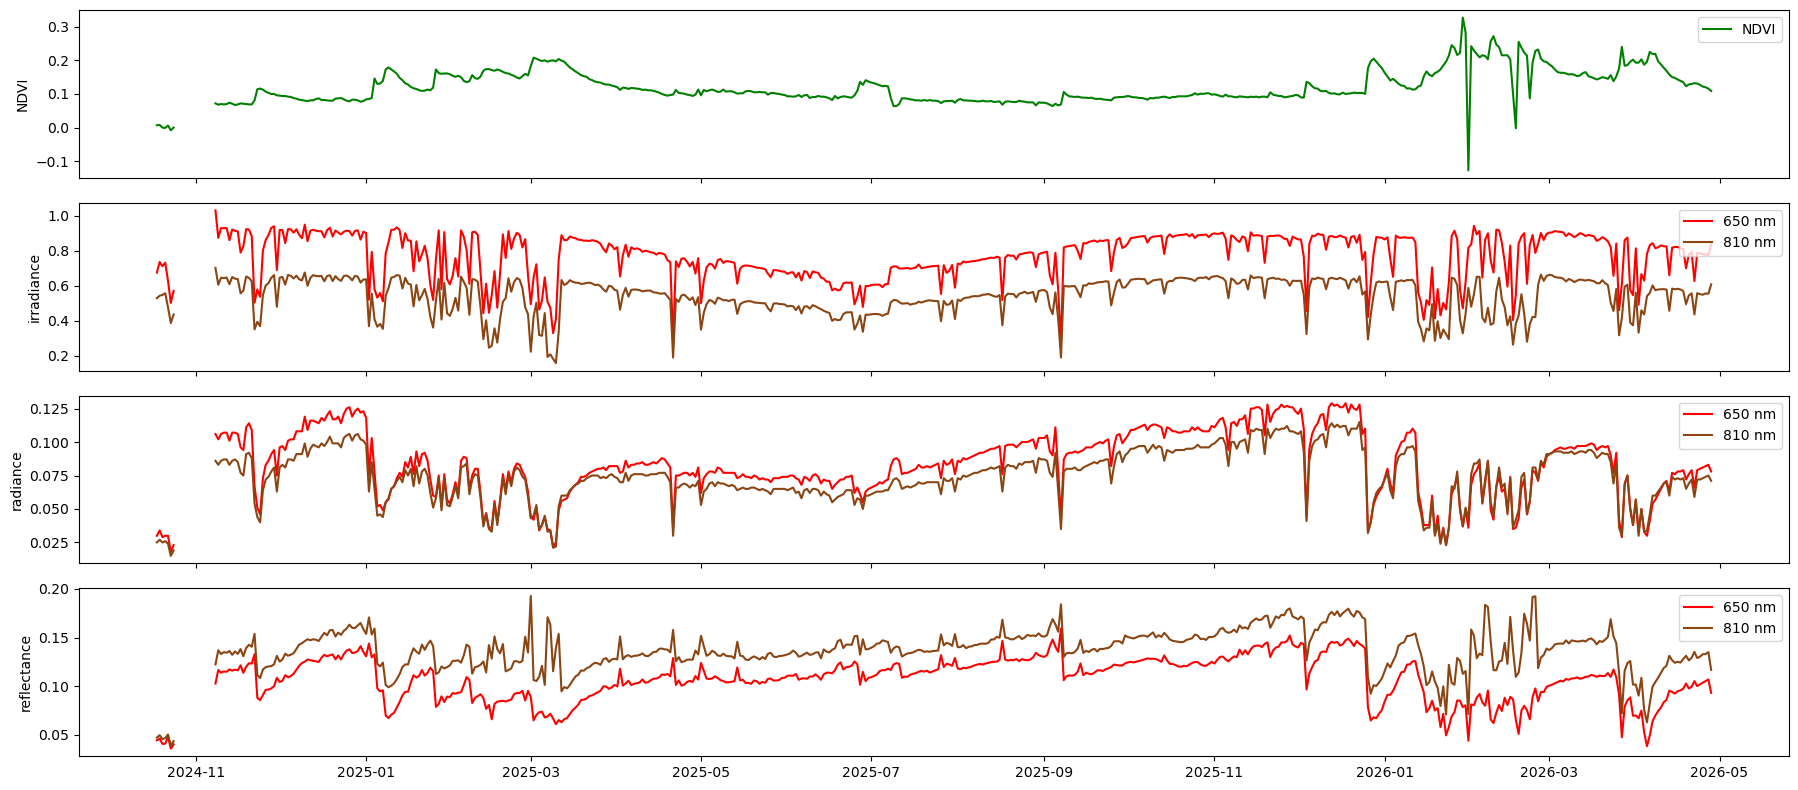

In [103]:
# Figure
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

# Subplot 1
ax1.plot(insitu_df.index, insitu_df['S2412_ndvi'], c='green', label='NDVI')
ax1.set_ylabel('NDVI')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(insitu_df.index, insitu_df['S2411_650-nm-irradiance_Wm-2nm-1'], label='650 nm', c='red')
ax2.plot(insitu_df.index, insitu_df['S2411_810-nm-irradiance_Wm-2nm-1'], label='810 nm', c='saddlebrown')
ax2.set_ylabel('irradiance')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(insitu_df.index, insitu_df['S2412_650-nm-radiance_Wm-2nm-1sr-1'], label='650 nm', c='red')
ax3.plot(insitu_df.index, insitu_df['S2412_810-nm-radiance_Wm-2nm-1sr-1'], label='810 nm', c='saddlebrown')
ax3.set_ylabel('radiance')
ax3.legend(loc='upper right')

# Subplot 4
ax4.plot(insitu_df.index, insitu_df['S2412_650-nm-reflectance'], label='650 nm', c='red')
ax4.plot(insitu_df.index, insitu_df['S2412_810-nm-reflectance'], label='810 nm', c='saddlebrown')
ax4.set_ylabel('reflectance')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

Datos S2-412 no estandarizados del ultimo periodo estable

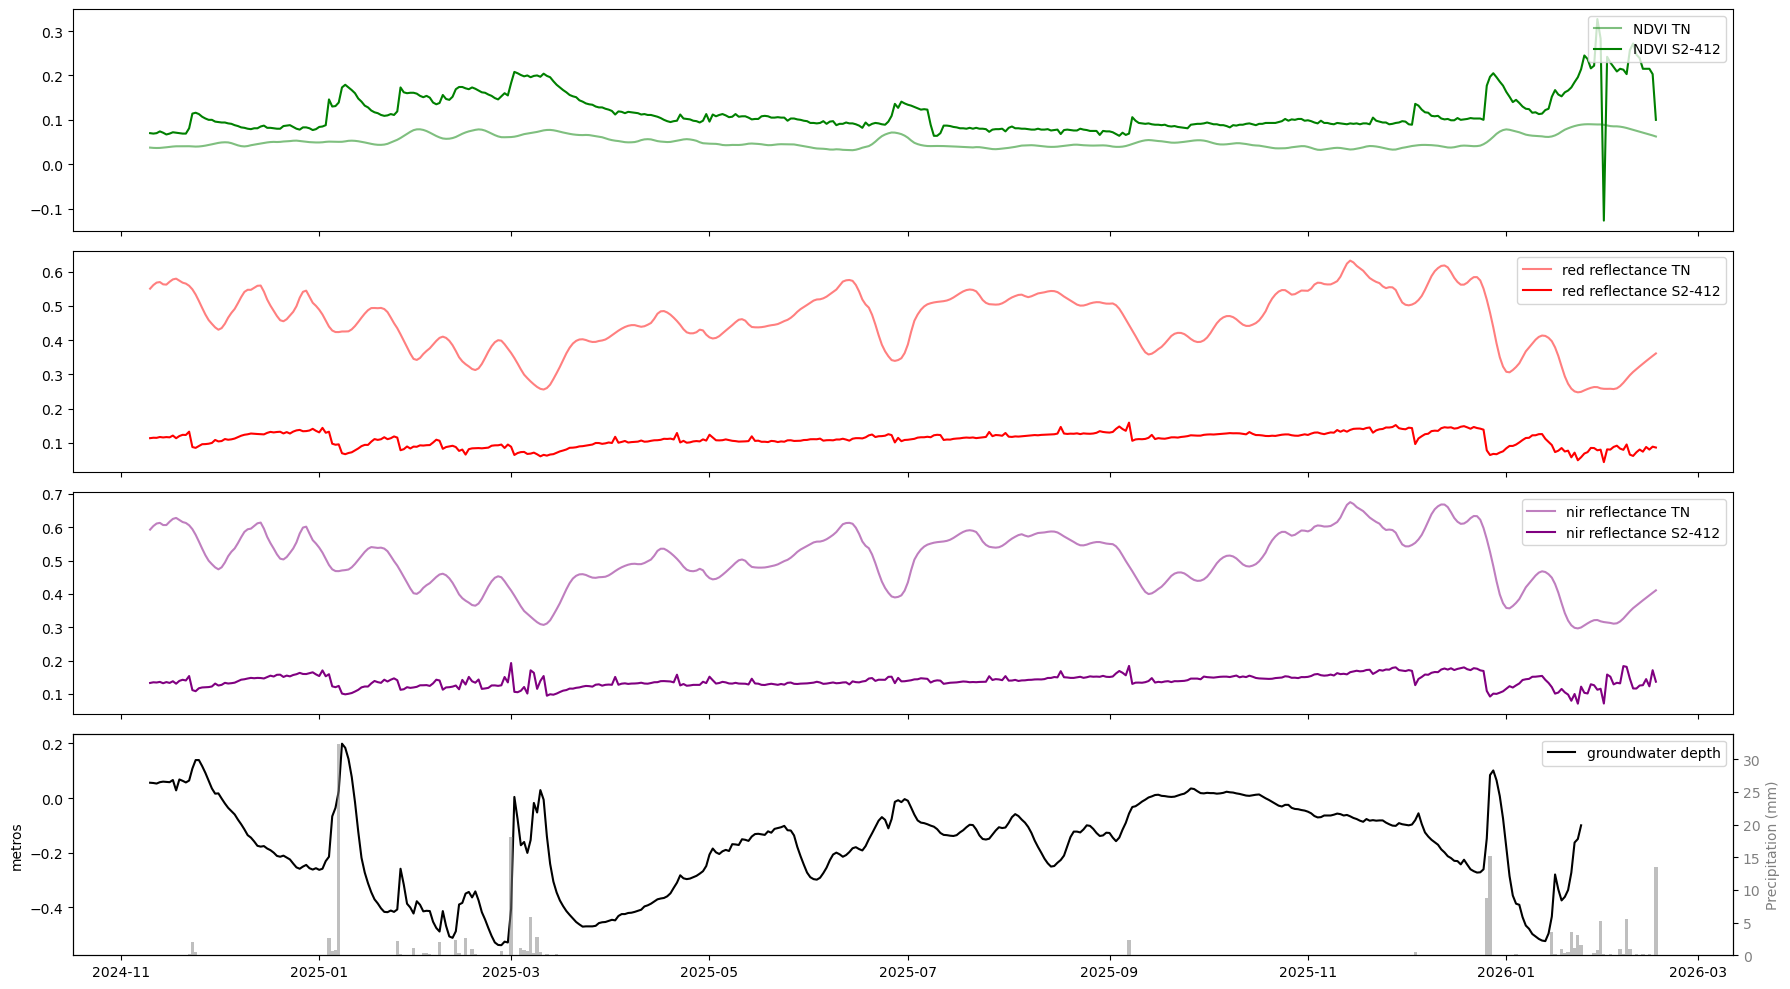

In [104]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

# Subplot 1
ax1.plot(fused_df.index, fused_df['s2_ndvi'], label='NDVI TN', c='green', alpha=0.5)
ax1.plot(fused_df.index, fused_df['S2412_ndvi'], c='green', label='NDVI S2-412')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(fused_df.index, fused_df['s2_B4'], label='red reflectance TN', c='red', alpha=0.5)
ax2.plot(fused_df.index, fused_df['S2412_650-nm-reflectance'], label='red reflectance S2-412', c='red')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(fused_df.index, fused_df['s2_B8'], label='nir reflectance TN', c='purple', alpha=0.5)
ax3.plot(fused_df.index, fused_df['S2412_810-nm-reflectance'], label='nir reflectance S2-412', c='purple')
ax3.legend(loc='upper right')

#Subplot 4
ax4.plot(fused_df.index, fused_df['SDH2PP01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax4.set_ylabel('metros')
ax4.legend(loc='upper right')
# Configure secondary y axis
ax5 = ax4.twinx()
ax5.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

Datos S2-412 estandarizados del ultimo periodo estable

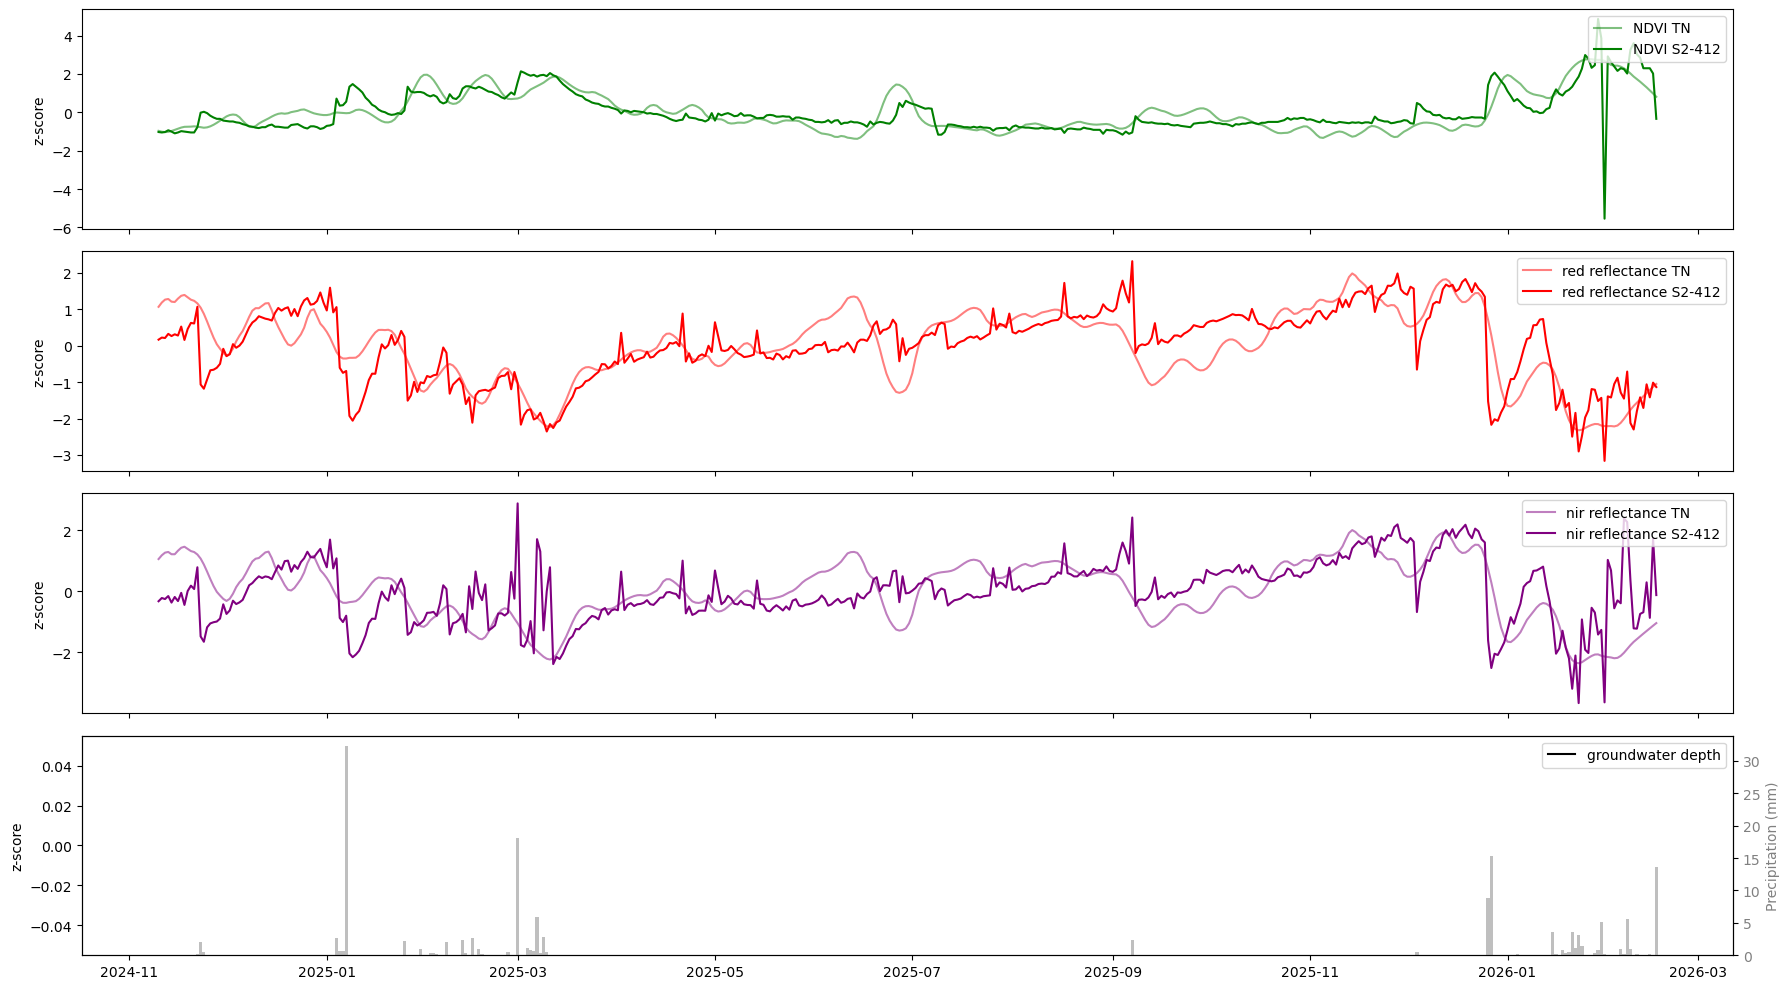

In [105]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

# Subplot 1
ax1.plot(z_df.index, z_df['s2_ndvi'], label='NDVI TN', c='green', alpha=0.5)
ax1.plot(z_df.index, z_df['S2412_ndvi'], c='green', label='NDVI S2-412')
ax1.set_ylabel('z-score')
ax1.legend(loc='upper right')

# Subplot 2
ax2.plot(z_df.index, z_df['s2_B4'], label='red reflectance TN', c='red', alpha=0.5)
ax2.plot(z_df.index, z_df['S2412_650-nm-reflectance'], label='red reflectance S2-412', c='red')
ax2.set_ylabel('z-score')
ax2.legend(loc='upper right')

# Subplot 3
ax3.plot(z_df.index, z_df['s2_B8'], label='nir reflectance TN', c='purple', alpha=0.5)
ax3.plot(z_df.index, z_df['S2412_810-nm-reflectance'], label='nir reflectance S2-412', c='purple')
ax3.set_ylabel('z-score')
ax3.legend(loc='upper right')

#Subplot 4
ax4.plot(z_df.index, z_df['SDH2PP01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax4.set_ylabel('z-score')
ax4.legend(loc='upper right')
# Configure secondary y axis
ax5 = ax4.twinx()
ax5.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()
